In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl

In [69]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [70]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


<function matplotlib.pyplot.show(close=None, block=None)>

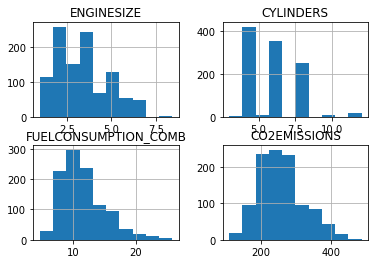

In [ ]:
cdf.hist()
plt.show()

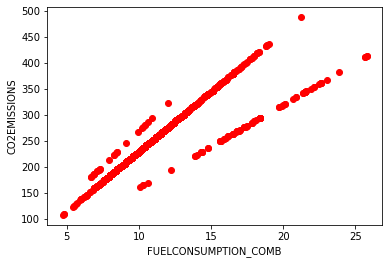

In [72]:
plt.scatter(cdf['FUELCONSUMPTION_COMB'], cdf['CO2EMISSIONS'], color='red')
plt.ylabel("CO2EMISSIONS")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.show()

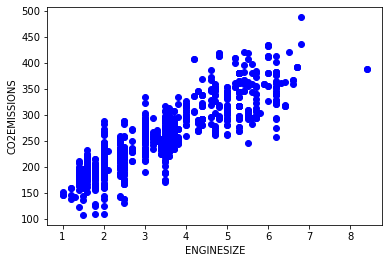

In [73]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

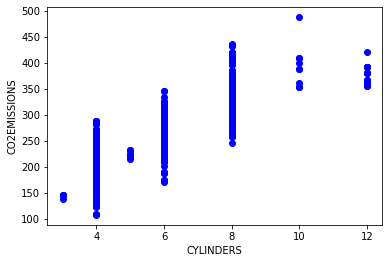

In [74]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2EMISSIONS")
plt.show()

In [75]:
msk = np.random.rand(len(df)) < 0.9
train = cdf[msk]
test = cdf[~msk]

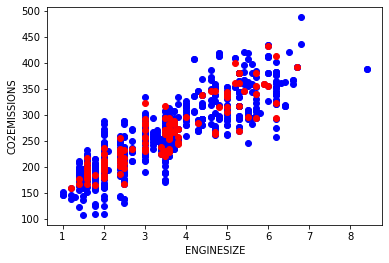

In [76]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.scatter(test.ENGINESIZE, test.CO2EMISSIONS, color='red')
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

In [ ]:
from sklearn import linear_model

regr = linear_model.LinearRegression()

x_train = np.array(train[['ENGINESIZE']])
y_train = np.array(train[['CO2EMISSIONS']])

regr.fit(x_train, y_train)

print(regr.coef_)
print(regr.intercept_)

[[39.00489155]]
[125.43246327]


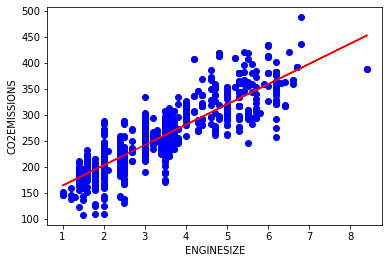

In [78]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(x_train, regr.coef_[0]*x_train + regr.intercept_, 'r')
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

In [89]:
from sklearn.metrics import r2_score

x_test = np.array(test[["ENGINESIZE"]])
y_test = np.array(test[["CO2EMISSIONS"]])
predicts = regr.predict(x_test)

print(f"MAE: {np.mean(np.absolute(predicts - y_test)):.2f}")
print(f"MSE: {np.mean((predicts - y_test)**2):.2f}")
print(f"R2: {r2_score(y_test, predicts)}")

MAE: 20.97
MSE: 764.05
R2: 0.8040025323622438
